# Adaptive optics loop data preprocessing for Machine Learning PSF Reconstruction (PSF-R-ML)

||||
|:---:|:---|:---|
|2026.04.10| Initial version | Dominique Humbert |




In [6]:
%matplotlib widget
import matplotlib.pyplot as plt
import h5py
import numpy as np
import pandas as pd
from matplotlib.patches import Circle
import ast


SMALL_SIZE = 20
MEDIUM_SIZE = 22
BIGGER_SIZE = 25
GPU = True
outputDir = "output/"
inputDir = "output/"


In [7]:
def convert_value(s):
    s = s.strip()
    low = s.lower()

    if low == "true":
        return True
    if low == "false":
        return False

    try:
        return ast.literal_eval(s)
    except Exception:
        return s

def read_metadata_file(path):
    df = pd.read_csv(
        path,
        sep="=",
        comment="#",
        header=None,
        names=["key", "value"],
        engine="python",
        skip_blank_lines=True,
    )

    df["key"] = df["key"].str.strip()
    df["value"] = df["value"].str.split("#").str[0].str.strip()
    df = df[df["key"].notna() & df["value"].notna() & (df["key"] != "")]

    out = df.set_index("key")["value"].to_dict()
    return {k: convert_value(v) for k, v in out.items()}

In [8]:
metadata = read_metadata_file("output/metadata.txt")
print(metadata["r0"])
print(metadata["NGSmagnitude"])
print(metadata["batchItSize"])

0.00375
4.5
137


(137, 97)


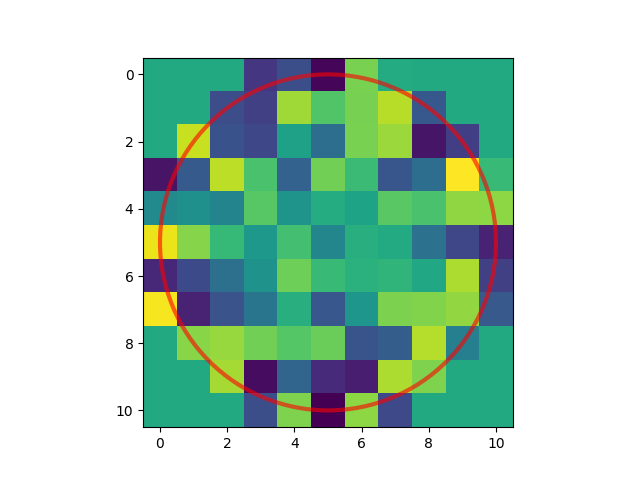

In [9]:
with h5py.File("output/ao_DM_1.h5", 'r') as temp:
    key = list(temp.keys())
    ao_DM = temp[key[0]][()]
    print(ao_DM.shape)
def circle_to_square(positions_1d, Nact1D=11):
    dm_array = np.zeros((Nact1D, Nact1D))
    y, x = np.ogrid[:Nact1D, :Nact1D]
    center = (Nact1D - 1) / 2
    dist_sq = (x - center)**2 + (y - center)**2
    # Get indices of N closest points to center
    sorted_indices = np.argsort(dist_sq.flatten())
    active_indices = sorted_indices[:len(positions_1d)]
    dm_array.flat[active_indices] = positions_1d
    return dm_array


dm_array = circle_to_square(ao_DM[0], Nact1D=int(metadata["nActWSF"] + 2*metadata["edge_act"]))


plt.close(0)
plt.figure(0)
plt.imshow(dm_array)
circle = Circle((5, 5), 5, color='red', fill=False, linewidth=3,alpha=0.6);
plt.gca().add_patch(circle)
# plt.savefig('output/dm_array.png', dpi=150, bbox_inches='tight')


(137, 80, 80)


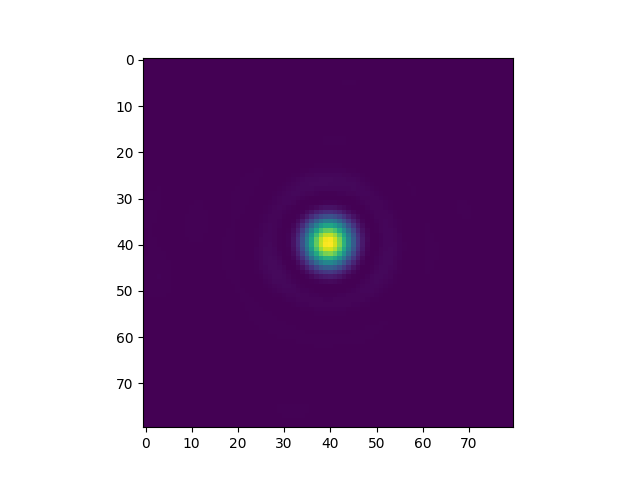

In [10]:
with h5py.File("output/ao_ipsf_1.h5", 'r') as temp:
    key = list(temp.keys())
    ipsf = temp[key[0]][()]
    print(ipsf.shape)

plt.close(1)
plt.figure(1)
plt.imshow(ipsf[8])
# plt.savefig('output/ipsf.png', dpi=150, bbox_inches='tight')


In [11]:
with h5py.File(inputDir+"ao_rwfe_"+str(1)+".h5", 'r') as temp:
    key = list(temp.keys())
    ao_RWFE = temp[key[0]][()]
print(ao_RWFE[0])


FileNotFoundError: [Errno 2] Unable to synchronously open file (unable to open file: name = 'output/ao_rwfe_1.h5', errno = 2, error message = 'No such file or directory', flags = 0, o_flags = 0)

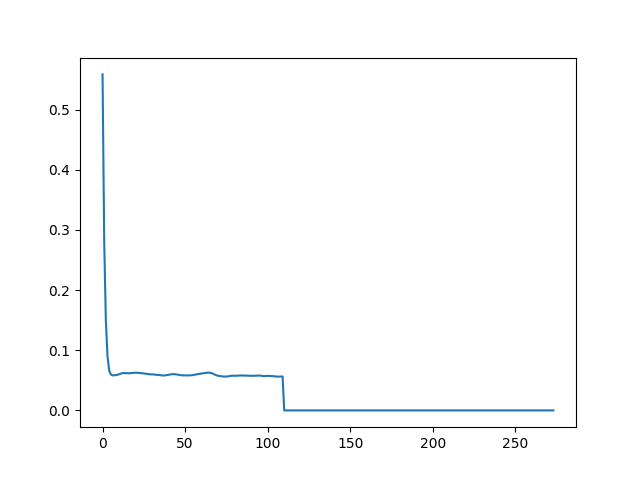

In [12]:
plt.close(0)
plt.figure(0)
plt.plot(ao_RWFE[0])
# plt.xlim(0, 10)
plt.show()


## Load datasets

In [ ]:


# for file_name in file_names:  
#     if file_name == file_names[0]:
#         for i in range(1, 5+1):
#             temp = h5py.File(inputDir+file_name+str(i)+".h5", 'r')
#             key = list(temp.keys())
#             ao_DM = temp[key[0]][()]
#     elif file_name == file_names[1]:
#         for i in range(1, 6):
#             temp = h5py.File(inputDir+file_name+str(i)+".h5", 'r')
#             key = list(temp.keys())
#             ao_lightfield = temp[key[0]][()]
#     elif file_name == file_names[2]:
#         for i in range(1, 6):
#             temp = h5py.File(inputDir+file_name+str(i)+".h5", 'r')
#             key = list(temp.keys())
#             ao_psf = temp[key[0]][()]
#     elif file_name == file_names[3]:
#         for i in range(1, 6):
#             temp = h5py.File(inputDir+file_name+str(i)+".h5", 'r')
#             key = list(temp.keys())
#             ao_rwfe = temp[key[0]][()]
#     elif file_name == file_names[4]:
#         for i in range(1, 6):
#             temp = h5py.File(inputDir+file_name+str(i)+".h5", 'r')
#             key = list(temp.keys())
#             ao_WFS = temp[key[0]][()]




# temp = h5py.File(inputDir+"ao_diff_limited_.h5", 'r')
# key = list(temp.keys())
# diff_lim = temp[key[0]][()]

# plt.close(0)
# plt.figure()
# plt.imshow(diff_lim**(1/2))

In [ ]:
# # print(ao_DM.shape)
# plt.close(0)
# plt.figure(0)
# plt.imshow(ao_DM[60,:].reshape(11,11))
# circle = Circle((5, 5), 4.5, color='red', fill=False, linewidth=3,alpha=0.6)
# plt.gca().add_patch(circle)


# print(ao_lightfield.shape)
# # print(ao_DM[:,0])
# plt.close(1)
# plt.figure(1)
# plt.imshow(ao_lightfield[50,:,:]**(1/4))

# print(ao_psf.shape)
# # print(ao_DM[:,0])
# plt.close(2)
# plt.figure(2)
# plt.imshow(ao_psf[88,:,:])
